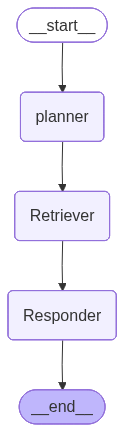

In [3]:
from typing import List
from pydantic import BaseModel
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph,END
from langchain_community.document_loaders import TextLoader
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS


llm = ChatOpenAI(model="gpt-4o-mini")

docs = TextLoader("internaldocs.txt").load()
splitter = RecursiveCharacterTextSplitter(chunk_size = 500, chunk_overlap=50)
chunks = splitter.split_documents(documents=docs)
vs = FAISS.from_documents(documents=chunks,embedding=OpenAIEmbeddings())
retriever = vs.as_retriever()

class RAGCotAGENT(BaseModel):
    question : str 
    answer : str = ""
    Retrieved_docs : List[Document] = []
    sub_steps : list[str] = []

def plan_steps(state:RAGCotAGENT)->RAGCotAGENT:
    prompt = f"Break the complex question into 2 to 3 reasoning questions \n\n {state.question}"
    result = llm.invoke(prompt)
    sub_qs = [line.strip("- ") for line in result.split("\n") if line.strip()]
    
    return state.model_copy(update={"sub_steps":sub_qs})

def retriever_per_step(state:RAGCotAGENT)->RAGCotAGENT:
    all_docs = []
    for sub in state.sub_steps:
        doc = llm.invoke(sub)
        all_docs.extend(doc)

    return state.model_copy(update={"Retrieved_docs": all_docs})

def generate_answer(state:RAGCotAGENT)->RAGCotAGENT:
    context = "\n\n".join(doc.page_content for doc in state.Retrieved_docs)
    prompt = f"""You are answering a complex question by using reasoning and reteirved docs

    Question : {state.question}

    Relevant Information : {context}

    now syntesize a well reasoned answer"""

    answer = llm.invoke(prompt).content.strip()

    return state.model_copy(update={"answer": answer})

builder = StateGraph(RAGCotAGENT)

builder.add_node("planner",plan_steps)
builder.add_node("Retriever",retriever_per_step)
builder.add_node("Responder",generate_answer)

builder.set_entry_point("planner")
builder.add_edge("planner","Retriever")
builder.add_edge("Retriever","Responder")
builder.add_edge("Responder",END)

graph = builder.compile()

graph

    

